<a href="https://colab.research.google.com/github/astrajoan/CSCE-636/blob/main/Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST

Import Keras


Load train and test dataset

In [18]:
import keras
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

Preprocess image


*   Reshape to 1D vector
*   Scale to [0,1]

Preprocess labels


*   One-hot encoding


In [20]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

from keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

Build the model architecture and compile

In [19]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(28 * 28,))) # 1st hidden
model.add(layers.Dense(64, activation='relu')) # 2nd hidden
model.add(layers.Dense(10, activation='softmax')) # Output layer
print(model.summary())

model.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_10 (Dense)             (None, 64)                50240     
_________________________________________________________________
dense_11 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_12 (Dense)             (None, 10)                650       
Total params: 55,050
Trainable params: 55,050
Non-trainable params: 0
_________________________________________________________________
None


Train the network

In [21]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 [==============================] - 2s 3ms/step - loss: 0.6288 - accuracy: 0.8377
Epoch 2/5
469/469 [==============================] - 1s 3ms/step - loss: 0.1784 - accuracy: 0.9490
Epoch 3/5
469/469 [==============================] - 1s 3ms/step - loss: 0.1280 - accuracy: 0.9633
Epoch 4/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0994 - accuracy: 0.9704
Epoch 5/5
469/469 [==============================] - 1s 3ms/step - loss: 0.0853 - accuracy: 0.9748


Test the network on test set

In [22]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('Test accuracy is:', test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.1009 - accuracy: 0.9709
Test accuracy is: 0.9708999991416931


# IMDB

Load train and test dataset

In [74]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

<string>:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:159: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/imdb.py:160: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 

What the review looks like back in words

In [75]:
# word_index is a dictionary mapping words to an integer index
word_index = imdb.get_word_index()
# We reverse it, mapping integer indices to words
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
# We decode the review; note that our indices were offset by 3
# because 0, 1 and 2 are reserved indices for "padding", "start of sequence", and "unknown".
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [76]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

Preprocess list of integer data using one-hot encoding

Preprocess labels into tensors

In [77]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

Build the model architecture and compile

In [78]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
print(model.summary())

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_24 (Dense)             (None, 16)                160016    
_________________________________________________________________
dense_25 (Dense)             (None, 16)                272       
_________________________________________________________________
dense_26 (Dense)             (None, 1)                 17        
Total params: 160,305
Trainable params: 160,305
Non-trainable params: 0
_________________________________________________________________
None


Partition dataset into train and validation set

In [79]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

Train the network

In [80]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=11,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/11
30/30 [==============================] - 1s 26ms/step - loss: 0.6335 - accuracy: 0.6525 - val_loss: 0.4222 - val_accuracy: 0.8562
Epoch 2/11
30/30 [==============================] - 1s 18ms/step - loss: 0.3465 - accuracy: 0.8923 - val_loss: 0.3076 - val_accuracy: 0.8841
Epoch 3/11
30/30 [==============================] - 1s 19ms/step - loss: 0.2232 - accuracy: 0.9305 - val_loss: 0.2783 - val_accuracy: 0.8909
Epoch 4/11
30/30 [==============================] - 1s 18ms/step - loss: 0.1641 - accuracy: 0.9513 - val_loss: 0.2776 - val_accuracy: 0.8896
Epoch 5/11
30/30 [==============================] - 1s 19ms/step - loss: 0.1272 - accuracy: 0.9653 - val_loss: 0.2893 - val_accuracy: 0.8851
Epoch 6/11
30/30 [==============================] - 1s 18ms/step - loss: 0.0979 - accuracy: 0.9763 - val_loss: 0.3078 - val_accuracy: 0.8835
Epoch 7/11
30/30 [==============================] - 1s 18ms/step - loss: 0.0734 - accuracy: 0.9852 - val_loss: 0.3292 - val_accuracy: 0.8805
Epoch 8/11
30

Plot the loss and accuracy curve against epoch

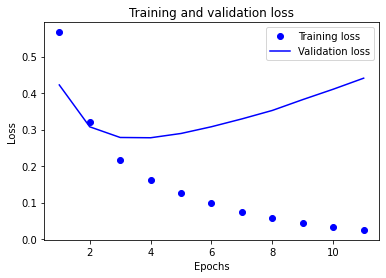

In [81]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

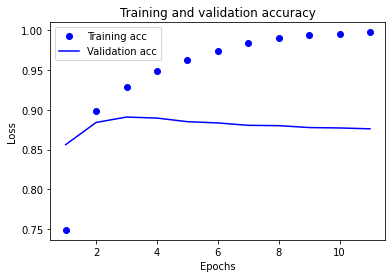

In [82]:
plt.clf()   # clear figure
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Train a new network with 4 epochs

In [83]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)

Epoch 1/4
49/49 [==============================] - 1s 11ms/step - loss: 0.5867 - accuracy: 0.6931
Epoch 2/4
49/49 [==============================] - 1s 11ms/step - loss: 0.2555 - accuracy: 0.9104
Epoch 3/4
49/49 [==============================] - 1s 11ms/step - loss: 0.1821 - accuracy: 0.9360
Epoch 4/4
49/49 [==============================] - 1s 11ms/step - loss: 0.1411 - accuracy: 0.9532


Test the network on test set

In [85]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy:",test_acc)

782/782 [==============================] - 2s 2ms/step - loss: 0.3203 - accuracy: 0.8770
Test accuracy: 0.8770400285720825


# Reuters

Load train and test dataset

In [86]:
from keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/reuters.py:148: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_train, y_train = np.array(xs[:idx]), np.array(labels[:idx])
/usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/datasets/reuters.py:149: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  x_test, y_test = np.array(xs[idx:]), np.array(labels[idx:])


Preprocess data and labels using one-hot encoding

In [87]:
# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)

one_hot_train_labels = to_categorical(train_labels)
one_hot_test_labels = to_categorical(test_labels)

Build the model architecture and compile

In [88]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))
print(model.summary())

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_30 (Dense)             (None, 64)                640064    
_________________________________________________________________
dense_31 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_32 (Dense)             (None, 46)                2990      
Total params: 647,214
Trainable params: 647,214
Non-trainable params: 0
_________________________________________________________________
None


Partition the data into train and validation set

In [89]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]

y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

Train the network

In [90]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=11,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/11
16/16 [==============================] - 1s 26ms/step - loss: 3.2414 - accuracy: 0.3517 - val_loss: 1.7703 - val_accuracy: 0.6460
Epoch 2/11
16/16 [==============================] - 0s 28ms/step - loss: 1.5608 - accuracy: 0.6901 - val_loss: 1.3002 - val_accuracy: 0.7180
Epoch 3/11
16/16 [==============================] - 0s 16ms/step - loss: 1.1039 - accuracy: 0.7678 - val_loss: 1.1333 - val_accuracy: 0.7500
Epoch 4/11
16/16 [==============================] - 0s 16ms/step - loss: 0.8355 - accuracy: 0.8240 - val_loss: 1.0359 - val_accuracy: 0.7750
Epoch 5/11
16/16 [==============================] - 0s 16ms/step - loss: 0.6827 - accuracy: 0.8519 - val_loss: 0.9775 - val_accuracy: 0.7950
Epoch 6/11
16/16 [==============================] - 0s 16ms/step - loss: 0.5430 - accuracy: 0.8881 - val_loss: 0.9236 - val_accuracy: 0.8150
Epoch 7/11
16/16 [==============================] - 0s 16ms/step - loss: 0.4291 - accuracy: 0.9123 - val_loss: 0.9020 - val_accuracy: 0.8170
Epoch 8/11
16

Plot the loss and accuarcy against epoch

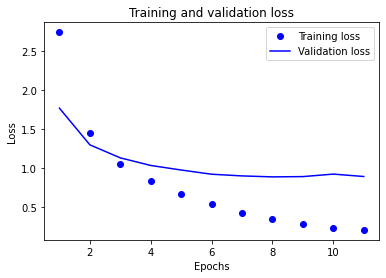

In [91]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

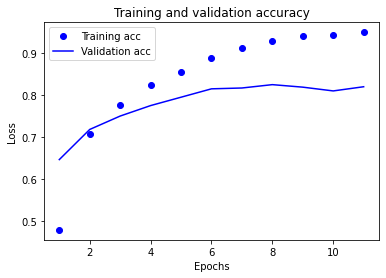

In [92]:
plt.clf()   # clear figure

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Train a new network with 8 epochs

In [93]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(partial_x_train,
          partial_y_train,
          epochs=8,
          batch_size=512,
          validation_data=(x_val, y_val))

Epoch 1/8
16/16 [==============================] - 1s 23ms/step - loss: 3.0360 - accuracy: 0.4376 - val_loss: 1.6798 - val_accuracy: 0.6450
Epoch 2/8
16/16 [==============================] - 0s 15ms/step - loss: 1.4580 - accuracy: 0.6985 - val_loss: 1.2866 - val_accuracy: 0.7230
Epoch 3/8
16/16 [==============================] - 0s 15ms/step - loss: 1.1003 - accuracy: 0.7643 - val_loss: 1.1276 - val_accuracy: 0.7520
Epoch 4/8
16/16 [==============================] - 0s 15ms/step - loss: 0.8383 - accuracy: 0.8278 - val_loss: 1.0288 - val_accuracy: 0.7800
Epoch 5/8
16/16 [==============================] - 0s 15ms/step - loss: 0.6548 - accuracy: 0.8691 - val_loss: 0.9784 - val_accuracy: 0.7880
Epoch 6/8
16/16 [==============================] - 0s 17ms/step - loss: 0.5507 - accuracy: 0.8861 - val_loss: 0.9438 - val_accuracy: 0.7970
Epoch 7/8
16/16 [==============================] - 0s 15ms/step - loss: 0.4296 - accuracy: 0.9080 - val_loss: 0.9167 - val_accuracy: 0.8080
Epoch 8/8
16/16 [===

Test the network on test set

In [94]:
test_loss, test_acc = model.evaluate(x_test, one_hot_test_labels)

print("Test accuracy:",test_acc)

71/71 [==============================] - 0s 3ms/step - loss: 0.9919 - accuracy: 0.7867
Test accuracy: 0.7867319583892822


# Boston Housing Price

Load train and test dataset

In [64]:
from keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) =  boston_housing.load_data()

Preprocess data


*   Normailize features



In [65]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std

test_data -= mean
test_data /= std

Build the model architecture and compile

In [66]:
def build_model():
    # Because we will need to instantiate
    # the same model multiple times,
    # we use a function to construct it.
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(train_data.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1))
    
    model.compile(optimizer='rmsprop', 
                  loss='mse', 
                  metrics=['mae'])
    return model

K-fold cross validation

In [67]:
from keras import backend as K

# Some memory clean-up
K.clear_session()

In [63]:
# history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [71]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 500
all_mae_histories = []
for i in range(k):
    print('processing fold #', i)
    # Prepare the validation data: data from partition # k
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # Prepare the training data: data from all other partitions
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0)
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0)

    # Build the Keras model (already compiled)
    model = build_model()
    # Train the model (in silent mode, verbose=0)
    history = model.fit(partial_train_data, partial_train_targets,
                        validation_data=(val_data, val_targets),
                        epochs=num_epochs, batch_size=1, verbose=0)
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


Plot validation MAE agaisnt epoch

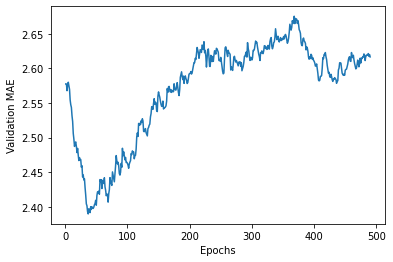

In [72]:
def smooth_curve(points, factor=0.9):
  smoothed_points = []
  for point in points:
    if smoothed_points:
      previous = smoothed_points[-1]
      smoothed_points.append(previous * factor + point * (1 - factor))
    else:
      smoothed_points.append(point)
  return smoothed_points

smooth_mae_history = smooth_curve(average_mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

Test the network on test set

In [73]:
# Get a fresh, compiled model.
model = build_model()
# Train it on the entirety of the data.
model.fit(train_data, train_targets,
          epochs=80, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

print("Test MAE score:",test_mae_score)

4/4 [==============================] - 0s 3ms/step - loss: 20.2765 - mae: 2.8192
Test MAE score: 2.8191895484924316
